***chi square test***

The Chi-Square test is a statistical method used to compare observed data with data we would expect to obtain according to a specific hypothesis. It is most commonly applied in:
- Goodness-of-fit tests: Does the sample data fit a particular distribution (e.g., normal distribution)?
- Test of independence: Are two categorical variables independent?
- Test of homogeneity: Do different populations have the same distribution?
The test statistic is:
\chi ^2=\sum \frac{(O_i-E_i)^2}{E_i}
where:
- O_i = observed frequency in category i
- E_i = expected frequency in category i

Definition:
Degrees of freedom represent the number of independent values in a dataset that can vary while still satisfying certain constraints. In other words, it’s the number of independent pieces of information available to estimate a parameter.

Imagine you’re splitting a budget of $100 among 5 categories. You can freely assign amounts to 4 categories, but the 5th is automatically determined (it must make the total $100). That means you had 4 degrees of freedom.






In [8]:
import numpy as np
observed=np.array([
    [250,200],
    [50,1000]
])
print(f"Dimesion of the array is : {observed.ndim}")
excepted=np.array([
    [90,360],
    [210,840]

])
print(type(excepted))
chisquare=((observed-excepted)**2/excepted).sum()
print(f"{chisquare:.4f}")

Dimesion of the array is : 2
<class 'numpy.ndarray'>
507.9365


In [9]:
from scipy.stats import chi2_contingency
chi2,p,dof,exp=chi2_contingency(observed,correction=False)
print(f"Chi Square :{chi2}")
print(f"p-value: {p}")
print(f"Degrees of freedom: {dof}")
print(f"Expected values: {exp}")

if p<0.05:
    print("Reject H0")
else:
    print("Fail to reject H0")

Chi Square :507.93650793650795
p-value: 1.7830898208664246e-112
Degrees of freedom: 1
Expected values: [[ 90. 360.]
 [210. 840.]]
Reject H0


In [3]:
from scipy.stats import chi2_contingency,chisquare
observed=[60,10,15,14,19,14]
expected=[22]*6
chi2,p=chisquare(f_obs=observed,f_exp=expected)
print(f"Chi-square: {chi2:.4f}")
print(f"P-value: {p:.6f}")

if p<0.05:
  print('Reject H0 i.e the die is baised')
else:
  print("Fail to reject H0 i.e the die is not baised")

Chi-square: 80.6364
P-value: 0.000000
Reject H0 i.e the die is baised


***Simple linear regression***

In [14]:
x=np.arange(0,30,0.27)
print(x[0:4])
y=0.1999*x+4.2999
print(y[0:4])
print(x.shape,y.shape)

[0.   0.27 0.54 0.81]
[4.2999   4.353873 4.407846 4.461819]
(112,) (112,)


In [15]:
split=int(x.shape[0]*0.8)
print(split)

89


In [ ]:
x_train,y_train=x[0:split],y[0:split]
x_test,y_test=x[split:],y[split:]

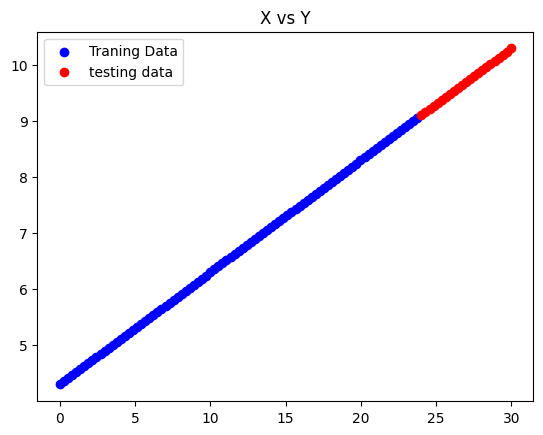

In [17]:
import matplotlib.pyplot as plt
def plot_data(x_train=x_train,x_test=x_test,y_train=y_train,y_test=y_test,predictions=None):
    plt.scatter(x_train,y_train,c='b',label="Traning Data")
    plt.scatter(x_test,y_test,c='r',label="testing data")
    if predictions is not None:
        plt.plot(x_test,predictions,c='g',label="Predictions")
    plt.legend()
    plt.title("X vs Y")
    plt.show()
plot_data()
        

In [22]:
x_mean=np.mean(x_train)
y_mean=np.mean(y_train)
cov_x_y=(1/x_train.shape[0])*np.sum((x_train-x_mean)*(y_train-y_mean))
cov_x=(1/x_train.shape[0])*np.sum((x_train-x_mean)**2)
m=cov_x_y/cov_x
c=y_mean-m*x_mean
print(f'y={m}*x+{c}')

y=0.1999*x+4.2999


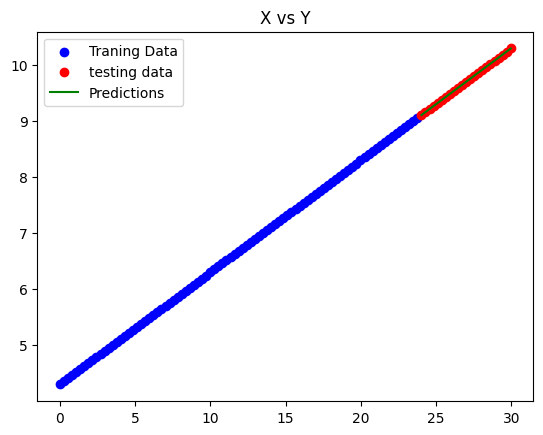

In [23]:
#Generate the predicition on the test set
y_preds=m*x_test+c
plot_data(predictions=y_preds)


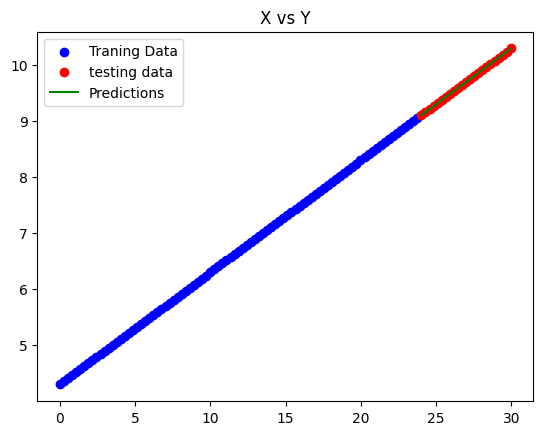

In [26]:
from sklearn.linear_model import LinearRegression
lr_model=LinearRegression()
#Train
lr_model.fit(x_train.reshape(-1,1),y_train)

#get predictions
y_preds=lr_model.predict(x_test.reshape(-1,1))
plot_data(predictions=y_preds)



In [28]:
x_train.reshape(-1,1)[0:10]

array([[0.  ],
       [0.27],
       [0.54],
       [0.81],
       [1.08],
       [1.35],
       [1.62],
       [1.89],
       [2.16],
       [2.43]])

In [29]:
x_train

array([ 0.  ,  0.27,  0.54,  0.81,  1.08,  1.35,  1.62,  1.89,  2.16,
        2.43,  2.7 ,  2.97,  3.24,  3.51,  3.78,  4.05,  4.32,  4.59,
        4.86,  5.13,  5.4 ,  5.67,  5.94,  6.21,  6.48,  6.75,  7.02,
        7.29,  7.56,  7.83,  8.1 ,  8.37,  8.64,  8.91,  9.18,  9.45,
        9.72,  9.99, 10.26, 10.53, 10.8 , 11.07, 11.34, 11.61, 11.88,
       12.15, 12.42, 12.69, 12.96, 13.23, 13.5 , 13.77, 14.04, 14.31,
       14.58, 14.85, 15.12, 15.39, 15.66, 15.93, 16.2 , 16.47, 16.74,
       17.01, 17.28, 17.55, 17.82, 18.09, 18.36, 18.63, 18.9 , 19.17,
       19.44, 19.71, 19.98, 20.25, 20.52, 20.79, 21.06, 21.33, 21.6 ,
       21.87, 22.14, 22.41, 22.68, 22.95, 23.22, 23.49, 23.76])

In [36]:
import statsmodels.api as sm
x_train_sm=sm.add_constant(x_train)
print(x_train_sm[:2])
x_test_sm=sm.add_constant(x_test)
print(x_test_sm[:2])
#fit the model
model=sm.OLS(y_train,x_train_sm).fit()#ordinary least square method
#view the summary
model.summary()

[[1.   0.  ]
 [1.   0.27]]
[[ 1.   24.03]
 [ 1.   24.3 ]]


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.015e+31
Date:                Tue, 10 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:28:51   Log-Likelihood:                 2884.2
No. Observations:                  89   AIC:                            -5764.
Df Residuals:                      87   BIC:                            -5759.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2999   4.34e-16   9.91e+15      0.000       4.300       4.300
x1             0.1999   3.15e-17   6.34e+15      0.000       0.200       0.200
==============================================================================
Omnibus:                        8.568   Durbin-Watson:                   0.172
Prob(Omnibus):                  0.014   Jarque-Bera (JB):                8.982
Skew:                           0.778   Prob(JB):                       0.0112
Kurtosis:                       2.973   Cond. No.                         27.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [42]:
from sklearn.model_selection import train_test_split
import pandas as pd
x1=np.arange(10,30,0.27)
x2=np.arange(50,70,0.27)
y=1.123*x1+2.123*x2+3.123
df=pd.DataFrame({'X1':x1,'x2':x2,'y':y})
x_data=df.drop(columns=['y'])
y_data=df['y']
x_train,x_test,y_train,y_test=train_test_split(x_data,y_data,test_size=0.2)
x_train_sm=sm.add_constant(x_train)
print(x_train_sm[:2])
x_test_sm=sm.add_constant(x_test)
print(x_test_sm[:2])
#fit the model
model=sm.OLS(y_train,x_train_sm).fit()#ordinary least square method
#view the summary
model.summary()




    const     X1     x2
27    1.0  17.29  57.29
11    1.0  12.97  52.97
    const     X1     x2
13    1.0  13.51  53.51
41    1.0  21.07  61.07


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.903e+31
Date:                Tue, 10 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:32:57   Log-Likelihood:                 1776.4
No. Observations:                  60   AIC:                            -3549.
Df Residuals:                      58   BIC:                            -3545.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0289   3.73e-17   7.74e+14      0.000       0.029       0.029
X1             1.0456   1.11e-15   9.38e+14      0.000       1.046       1.046
x2             2.2004   3.82e-16   5.76e+15      0.000       2.200       2.200
==============================================================================
Omnibus:                        0.446   Durbin-Watson:                   0.400
Prob(Omnibus):                  0.800   Jarque-Bera (JB):                0.166
Skew:                          -0.124   Prob(JB):                        0.921
Kurtosis:                       3.068   Cond. No.                     3.51e+17
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.95e-30. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [44]:

y_preds=model.predict(x_test_sm)
print(y_preds)

13    131.89646
41    156.43622
31    147.67202
46    160.81832
47    161.69474
36    152.05412
70    181.85240
1     121.37942
17    135.40214
58    171.33536
51    165.20042
65    177.47030
68    180.09956
28    145.04276
48    162.57116
dtype: float64


In [45]:
from sklearn.metrics import r2_score
print(r2_score(y_test,y_preds))

1.0


In [ ]:
x